<a href="https://colab.research.google.com/github/Kmhiiz/mi_proyecto/blob/main/CasoChileCompra_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CASO DE ESTUDIO: ANALISIS DE DATOS - CHILE COMPRA - MODALIDAD TRATO DIRECTO

Importaciones y configuracion


In [1]:
from numpy import object_
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)

df = pd.read_csv(
    'OC_maestra.csv',
    sep = ';',
    encoding='utf-8',
    thousands='.',
    decimal=','
)


print("Forma de la matriz", df.shape)
print("\nTipos de datos detectados:")
print("--Variables nulls--")
print(df.isnull().sum())
print(df.dtypes)

Forma de la matriz (49749, 13)

Tipos de datos detectados:
--Variables nulls--
codigoOC              0
FechaEnvioOC          0
MontoNetoOC_CLP       0
MontoTotalOC          0
NombreOC              0
UnidadCompra          0
RegionUnidadCompra    0
Institucion           0
Sector                0
Proveedor             0
EstadoOC              0
Año                   0
Semestre              0
dtype: int64
codigoOC               object
FechaEnvioOC           object
MontoNetoOC_CLP       float64
MontoTotalOC          float64
NombreOC               object
UnidadCompra           object
RegionUnidadCompra     object
Institucion            object
Sector                 object
Proveedor              object
EstadoOC               object
Año                     int64
Semestre                int64
dtype: object


In [2]:
# pd.to_datetime() convierte texto a formato fecha real que Python entiende
# dayfirst=True le dice: el primer número es el DÍA (formato chileno DD-MM-YYYY)
# Sin dayfirst=True, Pandas asume formato americano MM-DD-YYYY y se confunde
df['FechaEnvioOC'] = pd.to_datetime(df['FechaEnvioOC'], dayfirst=True)

# Verificar que quedó bien
print(df['FechaEnvioOC'].dtype)      # debe decir datetime64[ns]
print(df['FechaEnvioOC'].min())      # ahora sí ordena correctamente
print(df['FechaEnvioOC'].max())

datetime64[ns]
2023-01-03 00:00:00
2025-12-31 00:00:00


In [3]:
# Filtramos solo las OC con estado "ejecutado" o equivalente
# Primero veamos qué valores exactos existen en EstadoOC
print(df['EstadoOC'].unique())

['Aceptada' 'Recepcion Conforme' 'Enviada a Proveedor'
 'Solicitud de Cancelacion' 'En Proceso']


**INSIGHT 1:** Calidad Operacional y Tasa de Conversion

**INSIGHT 2**: Gasto total

In [4]:
# 1. FILTRADO AGRESIVO: Solo nos interesa la Región de Los Lagos, sin excepciones
# Usar .copy() para que Pandas no nos lance avisos
df_clean = df[df['RegionUnidadCompra'] == 'REGION DE LOS LAGOS'].copy()

# 2. Agrupar sobre este dataset limpio
gasto_sector = df_clean.groupby('Sector')['MontoNetoOC_CLP'].sum().reset_index()

# 3. calcular en Miles de Millones (para que el número sea más fácil de leer)
gasto_sector['Gasto_Billones_CLP'] = (gasto_sector['MontoNetoOC_CLP'] / 1000000000).round(1)

# 4. Ordenar
gasto_sector = gasto_sector.sort_values(by='Gasto_Billones_CLP', ascending=False)

print("--- REPARTO DEL PRESUPUESTO (En Miles de Millones de CLP) ---")
print(gasto_sector[['Sector', 'Gasto_Billones_CLP']])

--- REPARTO DEL PRESUPUESTO (En Miles de Millones de CLP) ---
            Sector  Gasto_Billones_CLP
1            SALUD              131.90
0  MUNICIPALIDADES               47.60


In [5]:
# groupby() agrupa las filas por las columnas que le indiques
# Equivale a GROUP BY sector, año en SQL
# ['MontoNetoOC_CLP'] selecciona solo esa columna para operar
# .sum() suma todos los montos dentro de cada grupo
gasto_total = df.groupby(['Sector', 'Año'])['MontoNetoOC_CLP'].sum()

# reset_index() convierte el resultado de groupby en una tabla normal
# Sin esto, Sector y Año quedan como índice (no como columnas), lo que dificulta operar después
gasto_total = gasto_total.reset_index()

# map('{:,.0f}'.format) aplica formato de miles con coma a cada valor
# Solo para visualización — no modifica el número real
gasto_total['MontoNetoOC_CLP'] = gasto_total['MontoNetoOC_CLP'].map('{:,.0f}'.format)

print("--GASTO TOTAL POR SECTOR Y AÑO--")
print(gasto_total)

--GASTO TOTAL POR SECTOR Y AÑO--
            Sector   Año MontoNetoOC_CLP
0  MUNICIPALIDADES  2023  22,416,661,288
1  MUNICIPALIDADES  2024  16,752,370,655
2  MUNICIPALIDADES  2025   8,480,630,476
3            SALUD  2023  43,149,103,901
4            SALUD  2024  57,239,254,315
5            SALUD  2025  31,461,935,228


**INSIGHT 3**: Volumen total de OC genradas por sector y año

In [6]:
# groupby agrupa por Sector y Año
# nunique() cuenta codigoOC únicos → equivale a COUNT(DISTINCT codigoOC)
volumen_oc = df.groupby(['Sector', 'Año'])['codigoOC'].nunique().reset_index()

# Renombramos para que sea descriptivo
volumen_oc = volumen_oc.rename(columns={'codigoOC': 'Total_OC'})

# Calculamos el porcentaje de cada fila sobre el total general
# .sum() aquí suma TODA la columna Total_OC (escalar, no groupby)
total_general = volumen_oc['Total_OC'].sum()

# Dividimos cada valor por el total y multiplicamos por 100
volumen_oc['Porcentaje (%)'] = (volumen_oc['Total_OC'] / total_general * 100).round(2)

print("--VOLUMEN OPERACIONAL POR SECTOR Y AÑO--")
print(volumen_oc)

--VOLUMEN OPERACIONAL POR SECTOR Y AÑO--
            Sector   Año  Total_OC  Porcentaje (%)
0  MUNICIPALIDADES  2023      9377           18.85
1  MUNICIPALIDADES  2024      8139           16.36
2  MUNICIPALIDADES  2025      3206            6.44
3            SALUD  2023     11780           23.68
4            SALUD  2024     12020           24.16
5            SALUD  2025      5227           10.51


In [7]:
# PASO 1 — Total OC generadas (todas)
volumen_total = df.groupby(['Sector', 'Año'])['codigoOC'].nunique().reset_index()
volumen_total = volumen_total.rename(columns={'codigoOC': 'OC_Generadas'})

# PASO 2 — Total OC ejecutadas (solo Aceptadas)
# Primero filtramos el df, luego agrupamos igual que arriba
df_ejecutadas = df[df['EstadoOC'] == 'Aceptada']
volumen_ejecutadas = df_ejecutadas.groupby(['Sector', 'Año'])['codigoOC'].nunique().reset_index()
volumen_ejecutadas = volumen_ejecutadas.rename(columns={'codigoOC': 'OC_Ejecutadas'})

# PASO 3 — Unimos ambas tablas
# merge() es el equivalente de JOIN en SQL
# on=['Sector', 'Año'] indica las columnas que actúan como llave
# how='left' mantiene todos los registros del df izquierdo aunque no haya match
volumen_comparativo = volumen_total.merge(volumen_ejecutadas, on=['Sector', 'Año'], how='left')

# PASO 4 — Tasa de ejecución
# Dividimos OC ejecutadas sobre generadas para saber qué % se concretó
volumen_comparativo['Tasa_Ejecucion (%)'] = (
    volumen_comparativo['OC_Ejecutadas'] /
    volumen_comparativo['OC_Generadas'] * 100
).round(2)

print("--VOLUMEN OPERACIONAL Y TASA DE EJECUCIÓN--")
print(volumen_comparativo)

--VOLUMEN OPERACIONAL Y TASA DE EJECUCIÓN--
            Sector   Año  OC_Generadas  OC_Ejecutadas  Tasa_Ejecucion (%)
0  MUNICIPALIDADES  2023          9377           6475               69.05
1  MUNICIPALIDADES  2024          8139           5243               64.42
2  MUNICIPALIDADES  2025          3206           1582               49.34
3            SALUD  2023         11780           1646               13.97
4            SALUD  2024         12020           1257               10.46
5            SALUD  2025          5227            776               14.85


**INSIGHT 4:** Concetracion proveedores

In [8]:
# PARTE A — ¿Cuántos proveedores únicos hay por sector?

# nunique() = COUNT(DISTINCT) en SQL

proveedores_por_sector = df.groupby('Sector')['Proveedor'].nunique().reset_index()
proveedores_por_sector = proveedores_por_sector.rename(columns={'Proveedor': 'Proveedores_Unicos'})

print("--TOTAL PROVEEDORES ÚNICOS POR SECTOR--")
print(proveedores_por_sector)

--TOTAL PROVEEDORES ÚNICOS POR SECTOR--
            Sector  Proveedores_Unicos
0  MUNICIPALIDADES                3561
1            SALUD                2589


In [9]:
# Paso 1 — filtrar solo SALUD
df_salud = df[df['Sector'] == 'SALUD']

# Paso 2 — agrupar sobre el df filtrado
oc_por_proveedor_salud = df_salud.groupby('Proveedor')['codigoOC'].nunique().reset_index()

# Paso 3 — renombrar
oc_por_proveedor_salud = oc_por_proveedor_salud.rename(columns={'codigoOC': 'Total_OC'})

# Paso 4 — ordenar SOLO por Total_OC, ya no necesitas Sector
oc_por_proveedor_salud = oc_por_proveedor_salud.sort_values('Total_OC', ascending=False)

print("--TOP 10 PROVEEDORES SALUD--")
print(oc_por_proveedor_salud.head(10))

--TOP 10 PROVEEDORES SALUD--
                                          Proveedor  Total_OC
1788            OPCIONES SA SISTEMAS DE INFORMACION      1038
353      CENTRO MEDICO LOS ANDES DE PUERTO MOTT SPA       680
1304                 JOHNSON Y JOHNSON DE CHILE S A       510
410                     CLINICA DE PUERTO VARAS SPA       450
2506                                    VALTEK S.A.       407
163                               ARTHREX CHILE SPA       398
2384  STRYKER CORPORATION CHILE Y COMPANIA LIMITADA       333
1396             KAUFMANN S A VEHICULOS MOTORIZADOS       325
1199    INTERNATIONAL TELEMEDICAL SYSTEMS CHILE SPA       315
448                  COMERCIAL KENDALL (CHILE) LTDA       308


In [10]:
#Paso 1 — filtrar solo MUNICIPALIDADES
df_muni = df[df['Sector'] == 'MUNICIPALIDADES']

# Paso 2 — agrupar sobre el df filtrado
oc_por_proveedor_muni = df_muni.groupby('Proveedor')['codigoOC'].nunique().reset_index()

# Paso 3 — renombrar
oc_por_proveedor_muni = oc_por_proveedor_muni.rename(columns={'codigoOC': 'Total_OC'})

# Paso 4 — ordenar SOLO por Total_OC, ya no necesitas Sector
oc_por_proveedor_muni = oc_por_proveedor_muni.sort_values('Total_OC', ascending=False)

print("--TOP 10 PROVEEDORES MUNICIPALIDADES--")
print(oc_por_proveedor_muni.head(10))

--TOP 10 PROVEEDORES MUNICIPALIDADES--
                                            Proveedor  Total_OC
3354                    TRANSPORTES DEL ESTUARIO S.A.      1608
1861               KAUFMANN S A VEHICULOS MOTORIZADOS       593
3366                         TRANSPORTES PUELCHE S.A.       529
875                      DIFOR CHILE SOCIEDAD ANONIMA       336
2798                SALINAS Y FABRES SOCIEDAD ANONIMA       292
3430                                      VALTEK S.A.       239
903    DISTRIBUIDORA Y COMERCIALIZADORA MANOSALVA SPA       211
3058                   SOC PERIODISTICA ARAUCANIA S A       199
2116                    MARCOS IVAN MALDONADO CARCAMO       186
603   COMERCIALIZADORA ANDREA PINILLA LLANOS E.I.R.L.       185


In [11]:
total_oc_muni = df[df['Sector'] == 'MUNICIPALIDADES']['codigoOC'].nunique()

total_oc_estuario = df[
    (df['Sector'] == 'MUNICIPALIDADES') &
    (df['Proveedor'] == 'TRANSPORTES DEL ESTUARIO S.A.')
]['codigoOC'].nunique()

pct_estuario = round((total_oc_estuario / total_oc_muni * 100), 2)

print(f"Total OC Municipalidades: {total_oc_muni}")
print(f"OC Transportes del Estuario: {total_oc_estuario}")
print(f"Concentración: {pct_estuario}%")

Total OC Municipalidades: 20722
OC Transportes del Estuario: 1608
Concentración: 7.76%


In [12]:
total_oc_salud = df[df['Sector'] == 'SALUD']['codigoOC'].nunique()

total_oc_sistemas = df[
    (df['Sector'] == 'SALUD') &
    (df['Proveedor'] == 'OPCIONES SA SISTEMAS DE INFORMACION')
]['codigoOC'].nunique()

pct_sistemas = round((total_oc_sistemas / total_oc_salud * 100), 2)

print(f"Total OC Salud: {total_oc_salud}")
print(f"OC Sistemas de Informacion: {total_oc_sistemas}")
print(f"Concentración: {pct_sistemas}%")

Total OC Salud: 29027
OC Sistemas de Informacion: 1038
Concentración: 3.58%


Diversificacion proveedores en 2 pasos

In [13]:
# PASO 1 — Por cada institución, cuántos proveedores únicos tiene

diversidad = df.groupby(['Sector', 'Institucion']).agg(
    Proveedores_Unicos=('Proveedor', 'nunique'),   # cuántos proveedores distintos
    Total_OC=('codigoOC', 'nunique')               # cuántas OC únicas
).reset_index()

# Ratio de concentración → OC por proveedor (mientras más alto, menos diversidad)
# Si una institución tiene 100 OC y 5 proveedores → 20 OC por proveedor (concentrado)
# Si tiene 100 OC y 80 proveedores → 1.25 OC por proveedor (diversificado)
diversidad['OC_por_Proveedor'] = (
    diversidad['Total_OC'] / diversidad['Proveedores_Unicos']
).round(2)

# Ordenamos de mayor a menor concentración
diversidad = diversidad.sort_values('OC_por_Proveedor', ascending=False)

print("--CONCENTRACIÓN POR INSTITUCIÓN--")
print(diversidad.head(15))

--CONCENTRACIÓN POR INSTITUCIÓN--
             Sector                                        Institucion  \
13  MUNICIPALIDADES                       I MUNICIPALIDAD DE HUALAIHUE   
39            SALUD  HOSPITAL PUERTO MONTT SERVICIO DE SALUD DEL RE...   
7   MUNICIPALIDADES                         I MUNICIPALIDAD DE CHONCHI   
36            SALUD                               HOSPITAL BASE OSORNO   
40            SALUD                           SERVICIO DE SALUD CHILOE   
12  MUNICIPALIDADES                       I MUNICIPALIDAD DE FUTALEUFU   
47            SALUD  SERVICIO NACIONAL DE SALUD HOSPITAL DE PUERTO ...   
25  MUNICIPALIDADES                         I MUNICIPALIDAD DE QUEILEN   
49            SALUD                       SERVICIO SALUD DEL RELONCAVI   
32  MUNICIPALIDADES                      ILUSTRE MUNICIPALIDAD COCHAMO   
10  MUNICIPALIDADES                          I MUNICIPALIDAD DE FRESIA   
34  MUNICIPALIDADES      ILUSTRE MUNICIPALIDAD DE SAN JUAN DE LA COSTA   
43  

In [14]:
# Para cada institución, cuántas OC tiene su proveedor principal
# Agrupar por Institución + Proveedor y contamos OC únicas
oc_inst_prov = df.groupby(
    ['Sector', 'Institucion', 'Proveedor']
)['codigoOC'].nunique().reset_index()

oc_inst_prov = oc_inst_prov.rename(columns={'codigoOC': 'OC_Proveedor'})

# idxmax() encuentra el índice de la fila con mayor valor por grupo
# Equivale a quedarse con el TOP 1 por institución
# transform('max') marca cuál es el máximo dentro de cada grupo
idx_max = oc_inst_prov.groupby(
    ['Sector', 'Institucion']
)['OC_Proveedor'].transform('max')

# Filtramos solo las filas donde el proveedor tiene el máximo de OC
proveedor_dominante = oc_inst_prov[oc_inst_prov['OC_Proveedor'] == idx_max].copy()

# Cruzamos con el total de OC por institución para calcular el %
proveedor_dominante = proveedor_dominante.merge(
    diversidad[['Sector', 'Institucion', 'Total_OC']],
    on=['Sector', 'Institucion']
)

# Porcentaje que concentra el proveedor dominante en esa institución
proveedor_dominante['Pct_Concentracion'] = (
    proveedor_dominante['OC_Proveedor'] /
    proveedor_dominante['Total_OC'] * 100
).round(2)

proveedor_dominante = proveedor_dominante.sort_values(
    'Pct_Concentracion', ascending=False
)

print("--PROVEEDOR DOMINANTE POR INSTITUCIÓN--")
print(proveedor_dominante.head(15))

--PROVEEDOR DOMINANTE POR INSTITUCIÓN--
             Sector                                        Institucion  \
16  MUNICIPALIDADES                         I MUNICIPALIDAD DE LAUTARO   
37            SALUD           COMPLEJO ASISTENCIAL DR.VICTOR RIOS RUIZ   
43            SALUD    SERVICIO DE SALUD COQUIMBO HOSPITAL DE COQUIMBO   
48            SALUD  SERVICIO NACIONAL DE SALUD HOSPITAL CARLOS VAN...   
32  MUNICIPALIDADES                   I MUNICIPALIDAD ESTACION CENTRAL   
46            SALUD   SERVICIO DE SALUD SUR HOSPITAL SANATORIO EL PINO   
15  MUNICIPALIDADES                       I MUNICIPALIDAD DE HUALAIHUE   
47            SALUD           SERVICIO DE SALUD VALDIVIA HOSPITAL BASE   
49            SALUD  SERVICIO NACIONAL DE SALUD HOSPITAL DE PUERTO ...   
50            SALUD   SERVICIO NACIONAL DE SALUD HOSPITAL DE RIO NEGRO   
35  MUNICIPALIDADES                   ILUSTRE MUNICIPALIDAD DE QUELLóN   
1   MUNICIPALIDADES  CORP MUNICIPAL DE EDUCACION Y SERVICIOS RAMON ...  

Limpieza registros fantasmas

In [15]:
instituciones_foraneas = [
    'SERVICIO DE SALUD VALDIVIA HOSPITAL BASE',
    'SERVICIO DE SALUD COQUIMBO HOSPITAL DE COQUIMBO',
    'SERVICIO DE SALUD SUR HOSPITAL SANATORIO EL PINO',
    'SERVICIO NACIONAL DE SALUD HOSPITAL CARLOS VAN BUREN',
    'COMPLEJO ASISTENCIAL DR.VICTOR RIOS RUIZ',
    'I MUNICIPALIDAD ESTACION CENTRAL',
    'CORP MUNICIPAL DE EDUCACION Y SERVICIOS RAMON FREIRE',
    'I MUNICIPALIDAD DE LAUTARO'

]

# ~isin() = NOT IN de SQL
df_limpio = df[~df['Institucion'].isin(instituciones_foraneas)].copy()

# Verificamos resultado
print(f"Filas antes: {len(df)}")
print(f"Filas después: {len(df_limpio)}")
print(f"Instituciones únicas: {df_limpio['Institucion'].nunique()}")

Filas antes: 49749
Filas después: 49722
Instituciones únicas: 43


In [16]:
# Sobreescribimos df con la versión limpia
df = df_limpio.copy()

print("✅ df actualizado con", len(df), "filas y", df['Institucion'].nunique(), "instituciones")

✅ df actualizado con 49722 filas y 43 instituciones


Investigacion e insights

In [17]:
# ── INSIGHT 4 — CONCENTRACIÓN DE PROVEEDORES ──────────────────────

# PARTE A — Diversidad de proveedores por institución
# Cuántos proveedores únicos tiene cada institución y cuántas OC
diversidad = df.groupby(['Sector', 'Institucion']).agg(
    Proveedores_Unicos=('Proveedor', 'nunique'),
    Total_OC=('codigoOC', 'nunique')
).reset_index()

# Ratio: OC por proveedor → más alto = más concentrado
diversidad['OC_por_Proveedor'] = (
    diversidad['Total_OC'] / diversidad['Proveedores_Unicos']
).round(2)

diversidad = diversidad.sort_values('OC_por_Proveedor', ascending=False)

print("--CONCENTRACIÓN POR INSTITUCIÓN--")
print(diversidad.head(15))
print()

# PARTE B — Proveedor dominante por institución
# Cuántas OC tiene el proveedor principal en cada institución
oc_inst_prov = df.groupby(
    ['Sector', 'Institucion', 'Proveedor']
)['codigoOC'].nunique().reset_index()

oc_inst_prov = oc_inst_prov.rename(columns={'codigoOC': 'OC_Proveedor'})

# transform('max') marca el máximo de OC dentro de cada institución
# sin colapsar las filas — equivale a un window function en SQL
idx_max = oc_inst_prov.groupby(
    ['Sector', 'Institucion']
)['OC_Proveedor'].transform('max')

# Nos quedamos solo con el proveedor que tiene el máximo por institución
proveedor_dominante = oc_inst_prov[
    oc_inst_prov['OC_Proveedor'] == idx_max
].copy()

# Cruzamos con diversidad para tener el Total_OC de cada institución
# merge = JOIN en SQL, on= es la llave, how='left' = LEFT JOIN
proveedor_dominante = proveedor_dominante.merge(
    diversidad[['Sector', 'Institucion', 'Total_OC']],
    on=['Sector', 'Institucion']
)

# Porcentaje de concentración del proveedor dominante
proveedor_dominante['Pct_Concentracion'] = (
    proveedor_dominante['OC_Proveedor'] /
    proveedor_dominante['Total_OC'] * 100
).round(2)

proveedor_dominante = proveedor_dominante.sort_values(
    'Pct_Concentracion', ascending=False
)

print("--PROVEEDOR DOMINANTE POR INSTITUCIÓN--")
print(proveedor_dominante.head(15))
print()

# PARTE C — Filtrar solo concentración estructural real
# Excluimos instituciones con menos de 50 OC (casos triviales)
# y nos quedamos con concentración mayor al 30%
concentracion_real = proveedor_dominante[
    (proveedor_dominante['Total_OC'] >= 50) &
    (proveedor_dominante['Pct_Concentracion'] >= 30)
].copy()

concentracion_real = concentracion_real.sort_values(
    'Pct_Concentracion', ascending=False
)

print("--CONCENTRACIÓN ESTRUCTURAL REAL--")
print(concentracion_real[[
    'Sector', 'Institucion', 'Proveedor',
    'OC_Proveedor', 'Total_OC', 'Pct_Concentracion'
]])

--CONCENTRACIÓN POR INSTITUCIÓN--
             Sector                                        Institucion  \
12  MUNICIPALIDADES                       I MUNICIPALIDAD DE HUALAIHUE   
35            SALUD  HOSPITAL PUERTO MONTT SERVICIO DE SALUD DEL RE...   
6   MUNICIPALIDADES                         I MUNICIPALIDAD DE CHONCHI   
32            SALUD                               HOSPITAL BASE OSORNO   
36            SALUD                           SERVICIO DE SALUD CHILOE   
11  MUNICIPALIDADES                       I MUNICIPALIDAD DE FUTALEUFU   
39            SALUD  SERVICIO NACIONAL DE SALUD HOSPITAL DE PUERTO ...   
23  MUNICIPALIDADES                         I MUNICIPALIDAD DE QUEILEN   
41            SALUD                       SERVICIO SALUD DEL RELONCAVI   
29  MUNICIPALIDADES                      ILUSTRE MUNICIPALIDAD COCHAMO   
9   MUNICIPALIDADES                          I MUNICIPALIDAD DE FRESIA   
31  MUNICIPALIDADES      ILUSTRE MUNICIPALIDAD DE SAN JUAN DE LA COSTA   
38  

/tmp/ipykernel_15792/1451722492.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Pct_Concentracion', y='Etiqueta_Y', data=data_viz, palette='Reds_r')


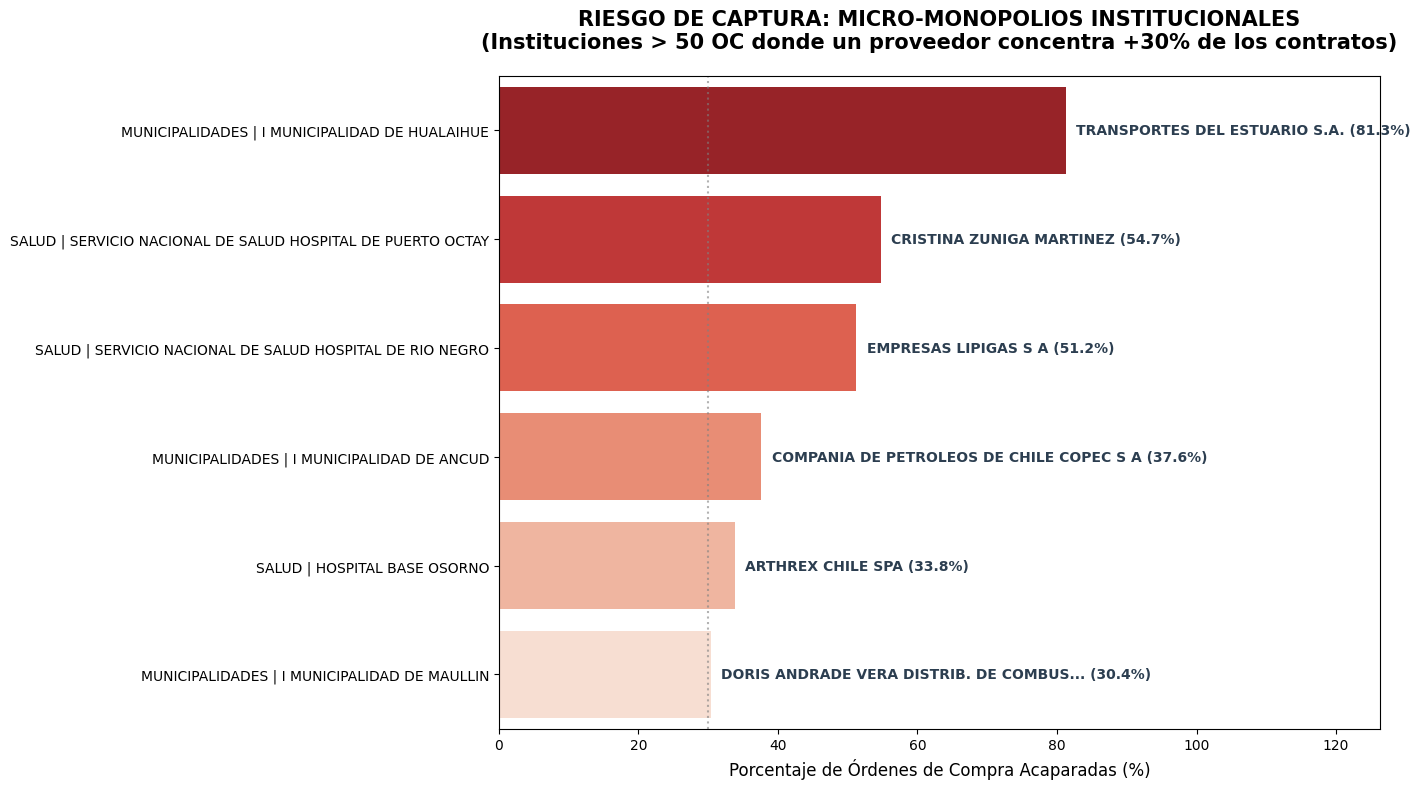

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# VISUALIZACIÓN: RIESGO DE CAPTURA (CORREGIDO)
# ==================================================

# 1. Preparamos los datos
data_viz = concentracion_real.sort_values('Pct_Concentracion', ascending=False).head(10).copy()

# Unimos el Sector y la Institución para que el eje Y sea súper claro
data_viz['Etiqueta_Y'] = data_viz['Sector'] + " | " + data_viz['Institucion']

plt.figure(figsize=(14, 8))

# 2. Gráfico de barras
ax = sns.barplot(x='Pct_Concentracion', y='Etiqueta_Y', data=data_viz, palette='Reds_r')

# 3. MÁGICA VISUAL: Texto AFUERA de la barra para que no se vea desprolijo
for i, p in enumerate(ax.patches):
    width = p.get_width()
    nombre_proveedor = data_viz.iloc[i]['Proveedor']

    # Cortamos el nombre si es grotescamente largo (más de 40 letras)
    if len(nombre_proveedor) > 40:
        nombre_proveedor = nombre_proveedor[:37] + '...'

    # Colocamos el texto a la derecha de la barra (width + 1)
    ax.text(width + 1.5, p.get_y() + p.get_height()/2,
            f'{nombre_proveedor} ({width:.1f}%)',
            va='center', ha='left', color='#2C3E50', fontweight='bold', fontsize=10)

# 4. Estética
plt.title('RIESGO DE CAPTURA: MICRO-MONOPOLIOS INSTITUCIONALES\n(Instituciones > 50 OC donde un proveedor concentra +30% de los contratos)',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Porcentaje de Órdenes de Compra Acaparadas (%)', fontsize=12)
plt.ylabel('')

# Damos más espacio dinámico al eje X para que los textos largos quepan sin cortarse
plt.xlim(0, data_viz['Pct_Concentracion'].max() + 45)

# Solo para mantener la referencia visual, una línea suave en el 30% (nuestro umbral de riesgo)
plt.axvline(30, color='grey', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('riesgo_captura_micro_monopolios_limpio.png', dpi=300)
plt.show()

INSGIT 5: OC Promedio

In [19]:
total_oc = df_clean.groupby(['Sector', 'Institucion'])['codigoOC'].count().reset_index()
total_oc.columns = ['Sector', 'Institucion', 'Total_Emitidas']

df_exito = df_clean[df_clean['EstadoOC'].isin(['Recepcion Conforme', 'Aceptada'])].copy()

exito_stats = df_exito.groupby(['Sector', 'Institucion']).agg(
    Completadas=('codigoOC', 'count'),
    Gasto_Total=('MontoNetoOC_CLP', 'sum')
).reset_index()


insight_final = pd.merge(total_oc, exito_stats, on=['Sector', 'Institucion'], how='left')
insight_final = insight_final.fillna(0)
insight_final['Tasa_Exito_%'] = (insight_final['Completadas'] / insight_final['Total_Emitidas'] * 100).round(1)

insight_final['Ticket_Promedio_MM'] = 0.0 # La creamos primero vacía
mask = insight_final['Completadas'] > 0 # Solo donde haya éxitos
insight_final.loc[mask, 'Ticket_Promedio_MM'] = (insight_final['Gasto_Total'] / insight_final['Completadas'] / 1000000).round(2)

insight_final = insight_final.sort_values(by='Total_Emitidas', ascending=False)

print("--- REPORTE FINAL DE EFICIENCIA POR INSTITUCIÓN ---")
columnas_ver = ['Institucion', 'Sector', 'Total_Emitidas', 'Completadas', 'Tasa_Exito_%', 'Ticket_Promedio_MM']
print(insight_final[columnas_ver].head(10))

--- REPORTE FINAL DE EFICIENCIA POR INSTITUCIÓN ---
                                          Institucion           Sector  \
39  HOSPITAL PUERTO MONTT SERVICIO DE SALUD DEL RE...            SALUD   
40                           SERVICIO DE SALUD CHILOE            SALUD   
49                       SERVICIO SALUD DEL RELONCAVI            SALUD   
32                      ILUSTRE MUNICIPALIDAD COCHAMO  MUNICIPALIDADES   
12                       I MUNICIPALIDAD DE FUTALEUFU  MUNICIPALIDADES   
13                       I MUNICIPALIDAD DE HUALAIHUE  MUNICIPALIDADES   
10                          I MUNICIPALIDAD DE FRESIA  MUNICIPALIDADES   
20                    I MUNICIPALIDAD DE PUERTO MONTT  MUNICIPALIDADES   
24                         I MUNICIPALIDAD DE PUYEHUE  MUNICIPALIDADES   
36                               HOSPITAL BASE OSORNO            SALUD   

    Total_Emitidas  Completadas  Tasa_Exito_%  Ticket_Promedio_MM  
39           11494        11356         98.80                5.99

In [20]:
# Investigando las 5 compras más caras de Cochamó
cochamo_detail = df_clean[df_clean['Institucion'].str.contains('COCHAMO')].sort_values(by='MontoNetoOC_CLP', ascending=False)
print("--- TOP COMPRAS COCHAMO ---")
print(cochamo_detail[['NombreOC', 'MontoNetoOC_CLP', 'Proveedor', 'EstadoOC']].head(5))

--- TOP COMPRAS COCHAMO ---
                                                NombreOC  MontoNetoOC_CLP  \
45695  EJECUCIÓN OBRA MEJORAMIENTO ESC. J.S.M. DE COC...    75,630,000.00   
45697  CONSTRUCCION PABELLON VERDE PARA ACTIVIDADES E...    34,211,765.00   
45260                REPARACIÓN SISTEMA ELÉCTRICO SOTOMÓ    27,338,710.00   
47551  ORDEN DE COMPRA GENERADA POR TRATO DIRECTO ID ...    21,385,189.00   
45094             MEJORAMIENTO MIRADOR PUEBLO DE COCHAMÓ    18,487,395.00   

                                              Proveedor            EstadoOC  
45695                             CONSTRUCTORA DECK SPA            Aceptada  
45697               CLAUDIO ALEJANDRO MALDONADO CARCAMO            Aceptada  
45260                  SERVICIOS ELÉCTRICOS DEL SUR SPA  Recepcion Conforme  
47551         SERVICIOS ELÉCTRICOS B&M E INGENIERÍA SPA  Recepcion Conforme  
45094  SERVICIOS INTEGRALES DE INFORMATICA GST E.I.R.L.            Aceptada  


In [21]:
# Investigando las 5 compras más caras de puyehue
cochamo_detail = df_clean[df_clean['Institucion'].str.contains('PUYEHUE')].sort_values(by='MontoNetoOC_CLP', ascending=False)
print("--- TOP COMPRAS Puyehue ---")
print(cochamo_detail[['NombreOC', 'MontoNetoOC_CLP', 'Proveedor', 'EstadoOC']].head(5))

--- TOP COMPRAS Puyehue ---
                                               NombreOC  MontoNetoOC_CLP  \
33421          MEJORAMIENTO ESPACIO PUBLICO SUSTENTABLE   113,445,378.00   
33591          REPOSICION CENTRO COMUNITARIO LOS SAUCES    96,638,655.46   
33607  CONSTRUCCION CENTRO COMUNITARIO SECTOR EL TAIQUE    91,596,638.60   
33409                                 SERVICIO  DE ASEO    40,966,386.55   
33392                                  SERVICIO DE ASEO    39,886,063.87   

                                   Proveedor             EstadoOC  
33421  INGENIERIA Y CONSTRUCCIONES S Y M SPA             Aceptada  
33591               CONSTRUCCIONES NEIRA SPA             Aceptada  
33607               CONSTRUCCIONES NEIRA SPA             Aceptada  
33409                  CONSULTORA CONVAL SPA  Enviada a Proveedor  
33392                  CONSULTORA CONVAL SPA           En Proceso  


In [22]:
# Investigando las 5 compras más caras de Fresia
cochamo_detail = df_clean[df_clean['Institucion'].str.contains('FRESIA')].sort_values(by='MontoNetoOC_CLP', ascending=False)
print("--- TOP COMPRAS Fresia ---")
print(cochamo_detail[['NombreOC', 'MontoNetoOC_CLP', 'Proveedor', 'EstadoOC']].head(5))

--- TOP COMPRAS Fresia ---
                                                NombreOC  MontoNetoOC_CLP  \
42686         EJECUCION PROY. MEJ. DIVERSAS MULTICANCHAS    66,417,587.00   
43048                 ARTISTA SHOW SEMANA FRESIANA 2024.    27,500,000.00   
42844  ORDEN DE COMPRA GENERADA POR TRATO DIRECTO ID ...    26,330,705.00   
43605                 ARTISTA SHOW SEMANA FRESIANA 2024.    23,000,000.00   
42885  EJECUCION PROY. NORM. SOL. SANITARIA POBL. BUSTAM    22,550,000.00   

                                Proveedor  EstadoOC  
42686  CONSTRUCTORA DANIEL GODOY LIMITADA  Aceptada  
43048                    MARQUEZ LIMITADA  Aceptada  
42844  KAUFMANN S A VEHICULOS MOTORIZADOS  Aceptada  
43605             CHUCAO PRODUCCIONES SPA  Aceptada  
42885        JAVIER ALEJANDRO SOTO BARRIA  Aceptada  


Visualizaciones hallazgos

/tmp/ipykernel_15792/2619683797.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Ticket_Promedio_MM', y='Institucion', data=top_10_volumen, palette=colores)


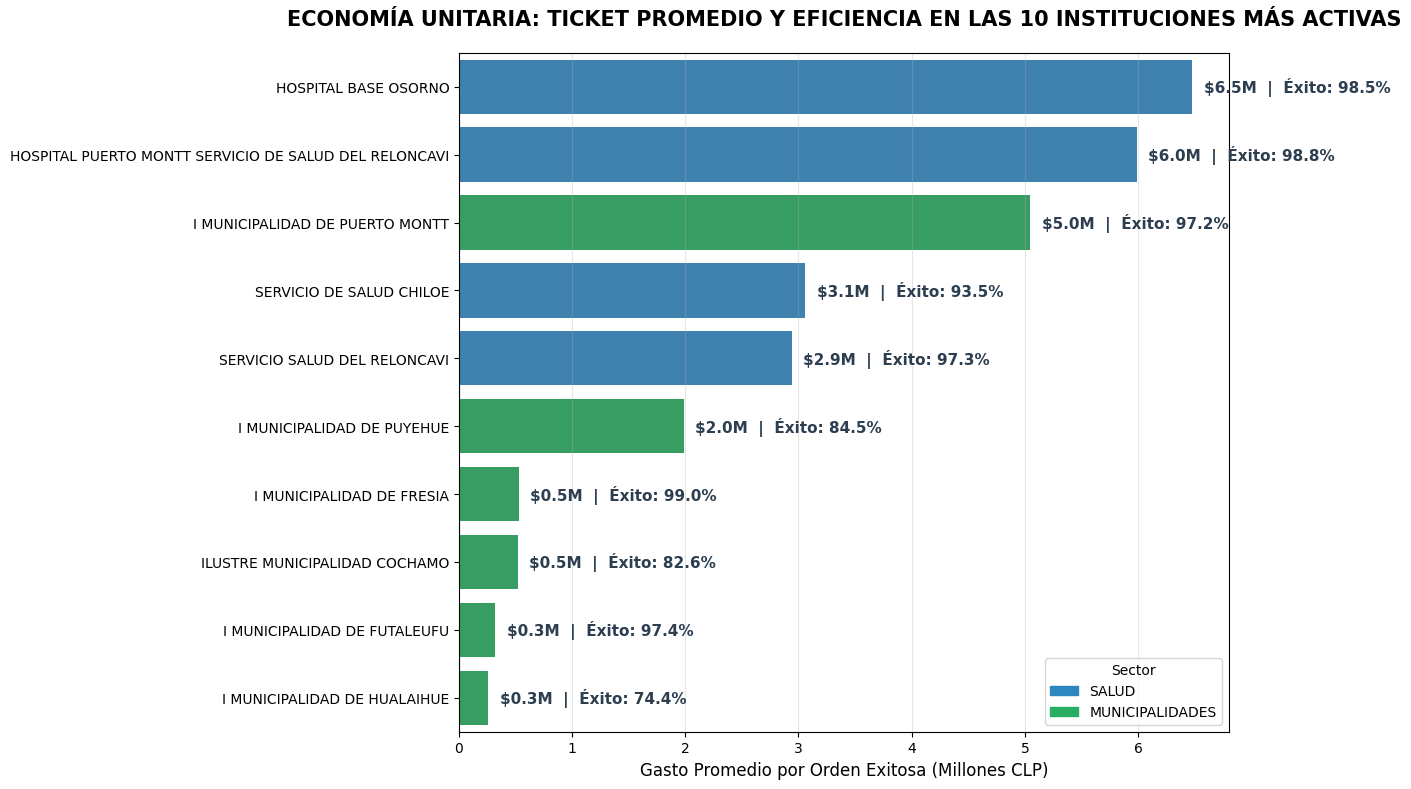

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# 1. Tomamos las 10 instituciones con MAYOR VOLUMEN de órdenes
top_10_volumen = insight_final.head(10).copy()

# Ordenamos esta lista por el Ticket Promedio de mayor a menor
top_10_volumen = top_10_volumen.sort_values(by='Ticket_Promedio_MM', ascending=False)

plt.figure(figsize=(14, 8))

# 2. Colores inteligentes: Azul para Salud, Verde para Municipalidades
colores =['#2E86C1' if sector == 'SALUD' else '#27AE60' for sector in top_10_volumen['Sector']]

# 3. Gráfico de Barras
ax = sns.barplot(x='Ticket_Promedio_MM', y='Institucion', data=top_10_volumen, palette=colores)

# 4. MÁGICA DE DATOS: Ponemos la Plata y el % de Éxito juntos al final de la barra
for i, p in enumerate(ax.patches):
    width = p.get_width()
    tasa_exito = top_10_volumen.iloc[i]['Tasa_Exito_%'] # Rescatamos la eficiencia

    # Texto que dice ej: "$5.4M | Éxito: 95.2%"
    ax.text(width + 0.1, p.get_y() + p.get_height()/2,
            f'${width:.1f}M  |  Éxito: {tasa_exito}%',
            va='center', fontweight='bold', color='#2C3E50', fontsize=11)

# 5. Estética y Títulos
plt.title('ECONOMÍA UNITARIA: TICKET PROMEDIO Y EFICIENCIA EN LAS 10 INSTITUCIONES MÁS ACTIVAS',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Gasto Promedio por Orden Exitosa (Millones CLP)', fontsize=12)
plt.ylabel('')

# 6. Leyenda personalizada
salud_patch = mpatches.Patch(color='#2E86C1', label='SALUD')
muni_patch = mpatches.Patch(color='#27AE60', label='MUNICIPALIDADES')
plt.legend(handles=[salud_patch, muni_patch], loc='lower right', title='Sector')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# Guardamos la imagen
plt.savefig('unit_economics_top10_ordenado.png', dpi=300)
plt.show()

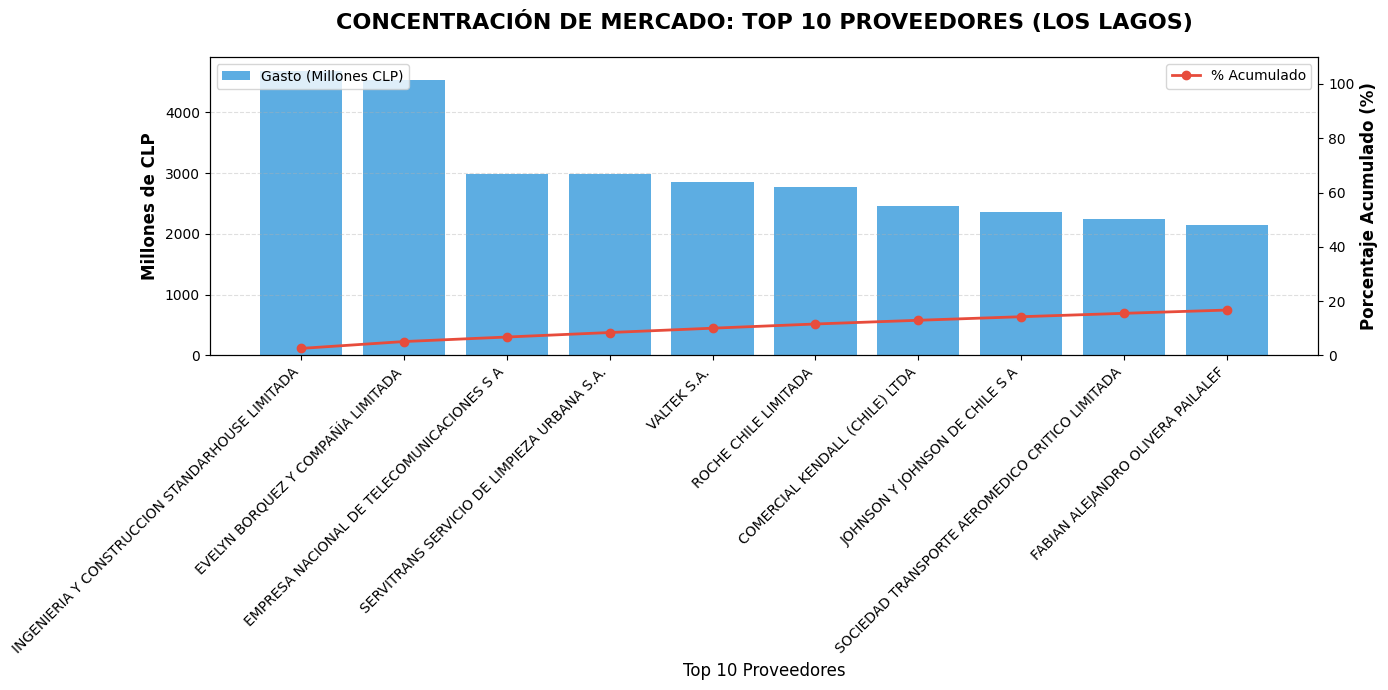

--- REVISIÓN DE PARETO ---
El Top 10 de proveedores concentra el 16.73% del gasto total regional.


In [24]:
import matplotlib.pyplot as plt


# Aseguramos que trabajamos sobre Los Lagos
df_lagos = df[df['RegionUnidadCompra'] == 'REGION DE LOS LAGOS'].copy()

# Agrupamos proveedores
proveedores = df_lagos.groupby('Proveedor')['MontoNetoOC_CLP'].sum().reset_index()
proveedores = proveedores.sort_values(by='MontoNetoOC_CLP', ascending=False)

# Calculamos acumulados para el Pareto
gasto_total = proveedores['MontoNetoOC_CLP'].sum()
proveedores['Porcentaje_%'] = (proveedores['MontoNetoOC_CLP'] / gasto_total) * 100
proveedores['Acumulado_%'] = proveedores['Porcentaje_%'].cumsum()
proveedores['Total_Ganado_MM'] = (proveedores['MontoNetoOC_CLP'] / 1000000).round(2)

# 2. GENERAR EL GRÁFICO
top_prov = proveedores.head(10).copy()
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras de Gasto
ax1.bar(top_prov['Proveedor'], top_prov['Total_Ganado_MM'], color='#5DADE2', label='Gasto (Millones CLP)')
ax1.set_ylabel('Millones de CLP', fontsize=12, fontweight='bold')
ax1.set_xlabel('Top 10 Proveedores', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)

# Línea de Pareto (Eje Secundario)
ax2 = ax1.twinx()
ax2.plot(top_prov['Proveedor'], top_prov['Acumulado_%'], color='#E74C3C', marker='o', linestyle='-', linewidth=2, label='% Acumulado')
ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 110)

# Detalles finales
plt.title('CONCENTRACIÓN DE MERCADO: TOP 10 PROVEEDORES (LOS LAGOS)', fontsize=16, fontweight='bold', pad=20)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Añadir leyenda
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('pareto_proveedores.png', dpi=300)
plt.show()

print("--- REVISIÓN DE PARETO ---")
print(f"El Top 10 de proveedores concentra el {top_prov['Acumulado_%'].max():.2f}% del gasto total regional.")

/tmp/ipykernel_15792/3950728292.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Sector', y='Gasto_Mil_Millones', data=gasto_sector, palette=['#2C3E50', '#95A5A6'])


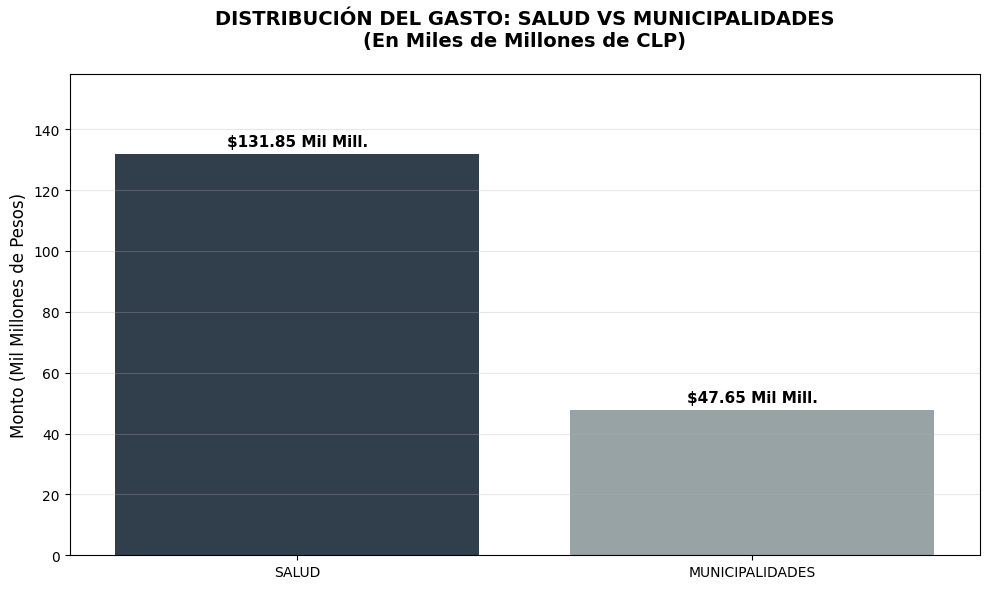

Sector salud tiene mayor gasto en OC por trato directo dentro de la Región de los Lagos 


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Recalculamos para mayor claridad (Usaremos el término 'Mil Millones')
gasto_sector['Gasto_Mil_Millones'] = gasto_sector['MontoNetoOC_CLP'] / 1000000000

plt.figure(figsize=(10, 6))
# Usamos un color profesional (Azul Petróleo y Gris)
ax = sns.barplot(x='Sector', y='Gasto_Mil_Millones', data=gasto_sector, palette=['#2C3E50', '#95A5A6'])

# Añadir las etiquetas de datos arriba de las barras de forma correcta
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f} Mil Mill.',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold',
                fontsize=11)

plt.title('DISTRIBUCIÓN DEL GASTO: SALUD VS MUNICIPALIDADES\n(En Miles de Millones de CLP)', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Monto (Mil Millones de Pesos)', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylim(0, gasto_sector['Gasto_Mil_Millones'].max() * 1.2) # Espacio para la etiqueta
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sectores_gasto_corregido.png', dpi=300)
plt.show()

print("Sector salud tiene mayor gasto en OC por trato directo dentro de la Región de los Lagos ")

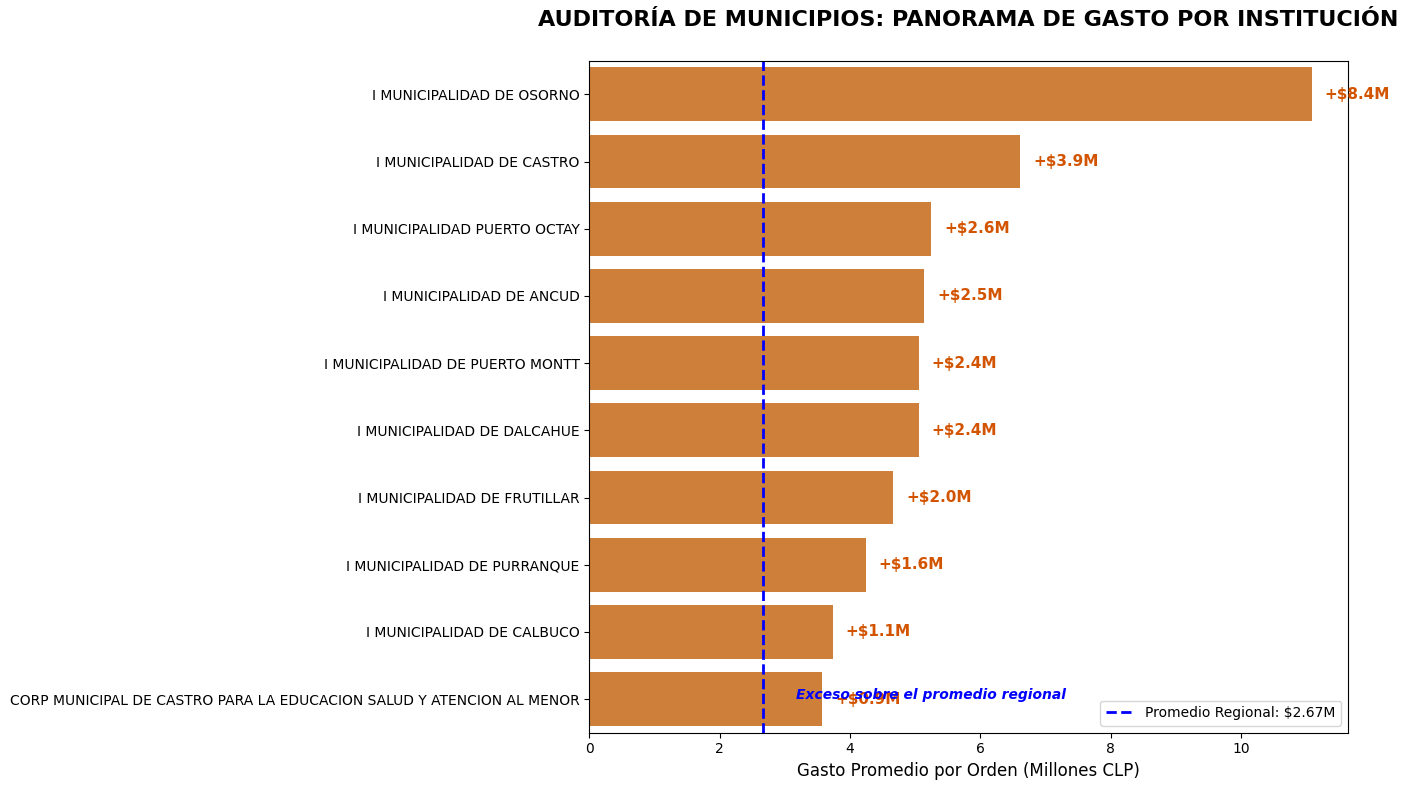

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de datos (Igual que el anterior)
valid_munis = df_clean[df_clean['Sector'] == 'MUNICIPALIDADES']['Institucion'].unique()
munis_lagos = insight_final[insight_final['Institucion'].isin(valid_munis)].copy()
munis_top = munis_lagos.nlargest(10, 'Ticket_Promedio_MM')
promedio_regional = munis_lagos['Ticket_Promedio_MM'].mean()

plt.figure(figsize=(14, 8)) # Un poco más ancho para las etiquetas

# 2. Colores: Naranja para los que superan el promedio
colors = ['#E67E22' if val > promedio_regional else '#BDC3C7' for val in munis_top['Ticket_Promedio_MM']]

ax = sns.barplot(x='Ticket_Promedio_MM', y='Institucion', data=munis_top,
                 palette=colors, hue='Institucion', legend=False)

# 3. MÁGIA DE AUDITORÍA: Añadir la desviación sobre las barras naranjas
for i, bar in enumerate(ax.patches):
    valor_actual = bar.get_width()
    if valor_actual > promedio_regional:
        desviacion = valor_actual - promedio_regional
        # Ponemos el texto justo al final de la barra
        ax.text(valor_actual + 0.2, bar.get_y() + bar.get_height()/2,
                f'+${desviacion:.1f}M',
                va='center', fontweight='bold', color='#D35400', fontsize=11)

# 4. Estética y etiquetas
plt.title('AUDITORÍA DE MUNICIPIOS: PANORAMA DE GASTO POR INSTITUCIÓN', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Gasto Promedio por Orden (Millones CLP)', fontsize=12)
plt.ylabel('')

# Línea de Promedio Regional
plt.axvline(promedio_regional, color='blue', linestyle='--', linewidth=2,
            label=f'Promedio Regional: ${promedio_regional:.2f}M')

# Anotación explicativa para el lector externo
plt.text(promedio_regional + 0.5, 9, 'Exceso sobre el promedio regional',
         color='blue', fontweight='bold', fontsize=10, style='italic')

plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig('auditoria_desviacion_ticket.png', dpi=300)
plt.show()

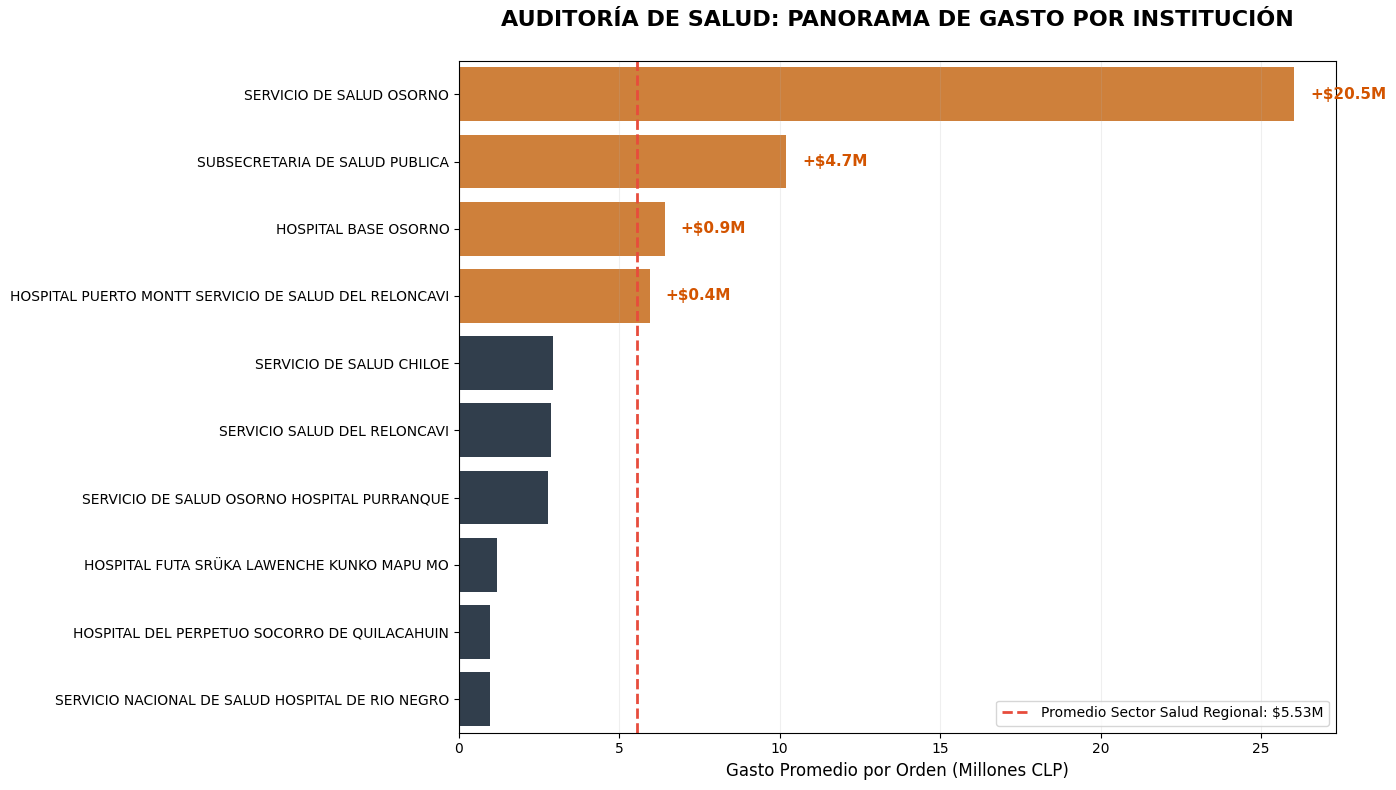

Total instituciones analizadas en Los Lagos: 11
Hospitales detectados: ['HOSPITAL BASE OSORNO', 'HOSPITAL DEL PERPETUO SOCORRO DE QUILACAHUIN', 'HOSPITAL FUTA SRÜKA LAWENCHE KUNKO MAPU MO', 'HOSPITAL PUERTO MONTT SERVICIO DE SALUD DEL RELONCAVI', 'SERVICIO DE SALUD CHILOE', 'SERVICIO DE SALUD OSORNO', 'SERVICIO DE SALUD OSORNO HOSPITAL PURRANQUE', 'SERVICIO NACIONAL DE SALUD HOSPITAL DE PUERTO OCTAY', 'SERVICIO NACIONAL DE SALUD HOSPITAL DE RIO NEGRO', 'SERVICIO SALUD DEL RELONCAVI', 'SUBSECRETARIA DE SALUD PUBLICA']


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FILTRO DE HIERRO: Creamos el dataset de Salud exclusivo de Los Lagos desde el origen
# Filtramos por el nombre EXACTO de la región para evitar fugas de Coquimbo o RM
df_salud_lagos = df[(df['RegionUnidadCompra'] == 'REGION DE LOS LAGOS') &
                    (df['Sector'] == 'SALUD')].copy()

# 2. Agregamos las estadísticas solo para estas instituciones
salud_stats = df_salud_lagos.groupby('Institucion').agg(
    Cant_OC=('codigoOC', 'count'),
    Gasto_Total=('MontoNetoOC_CLP', 'sum')
).reset_index()

# 3. Calculamos el Ticket Promedio (MM) y el Promedio del Sector en la Región
salud_stats['Ticket_Promedio_MM'] = (salud_stats['Gasto_Total'] / salud_stats['Cant_OC'] / 1000000).round(2)
promedio_salud_sector = salud_stats['Ticket_Promedio_MM'].mean()

# Tomamos el Top 10 para la gráfica
salud_top_final = salud_stats.nlargest(10, 'Ticket_Promedio_MM')

# 4. Gráfico de Auditoría
plt.figure(figsize=(14, 8))

# Colores: Naranja para los que superan la media de Los Lagos, Azul Petróleo para los demás
colors = ['#E67E22' if val > promedio_salud_sector else '#2C3E50' for val in salud_top_final['Ticket_Promedio_MM']]

ax = sns.barplot(x='Ticket_Promedio_MM', y='Institucion', data=salud_top_final,
                 palette=colors, hue='Institucion', legend=False)

# 5. Marcamos la desviación (+ Delta)
for i, bar in enumerate(ax.patches):
    valor_actual = bar.get_width()
    if valor_actual > promedio_salud_sector:
        desviacion = valor_actual - promedio_salud_sector
        ax.text(valor_actual + 0.5, bar.get_y() + bar.get_height()/2,
                f'+${desviacion:.1f}M',
                va='center', fontweight='bold', color='#D35400', fontsize=11)

# 6. Estética final
plt.title('AUDITORÍA DE SALUD: PANORAMA DE GASTO POR INSTITUCIÓN',
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Gasto Promedio por Orden (Millones CLP)', fontsize=12)
plt.ylabel('')

plt.axvline(promedio_salud_sector, color='#E74C3C', linestyle='--', linewidth=2,
            label=f'Promedio Sector Salud Regional: ${promedio_salud_sector:.2f}M')

plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()

plt.savefig('auditoria_salud_lagos_final.png', dpi=300)
plt.show()

# 📝 Verificación por consola para tu tranquilidad
print(f"Total instituciones analizadas en Los Lagos: {len(salud_stats)}")
print(f"Hospitales detectados: {salud_stats['Institucion'].tolist()}")

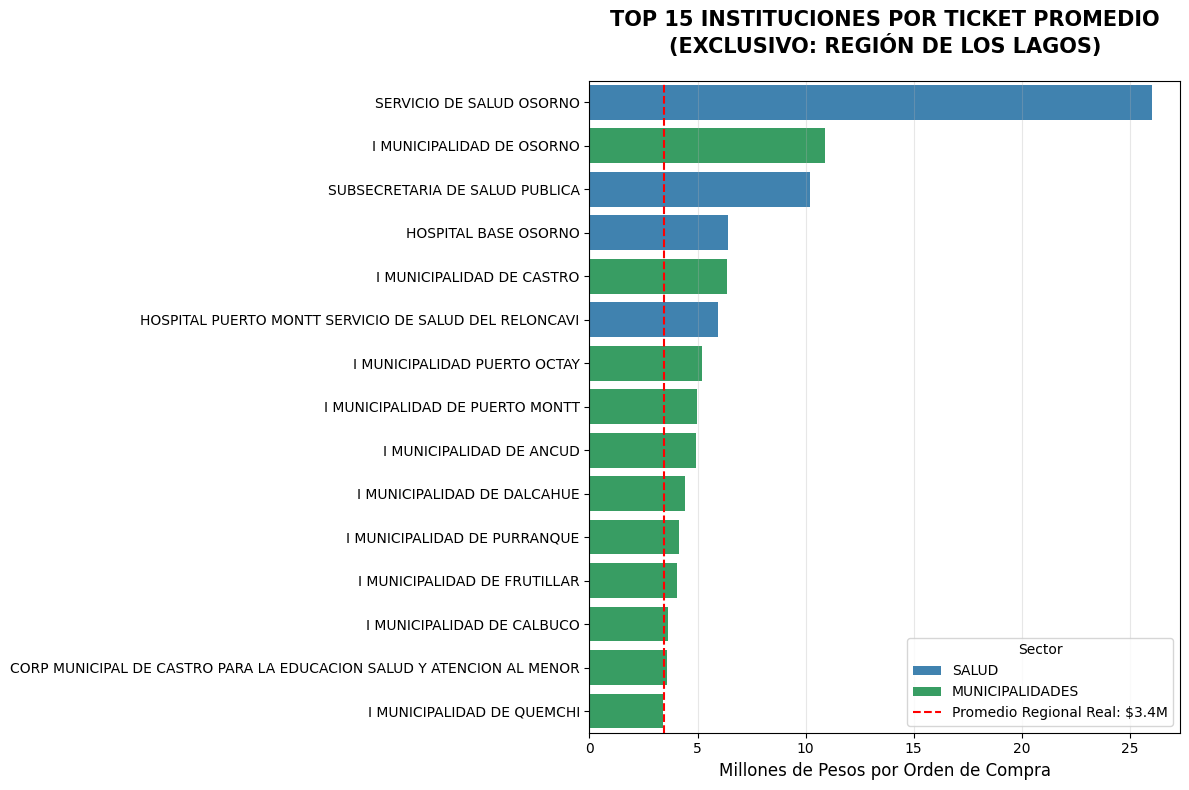

Éxito: Se filtraron 43 instituciones únicas de Los Lagos.


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FILTRO QUIRÚRGICO: Solo Región de Los Lagos desde la fuente original
df_solo_lagos = df[df['RegionUnidadCompra'] == 'REGION DE LOS LAGOS'].copy()

# 2. RECALCULAMOS LAS ESTADÍSTICAS: Para que el promedio y el Top sean puros
stats_regional = df_solo_lagos.groupby(['Sector', 'Institucion']).agg(
    Cant_OC=('codigoOC', 'count'),
    Gasto_Total=('MontoNetoOC_CLP', 'sum')
).reset_index()

# 3. Calculamos Ticket Promedio (en Millones) y la Media Regional Real
stats_regional['Ticket_Promedio_MM'] = (stats_regional['Gasto_Total'] / stats_regional['Cant_OC'] / 1000000).round(2)
promedio_regional_puro = stats_regional['Ticket_Promedio_MM'].mean()

# 4. Seleccionamos el Top 15 de Los Lagos
top_15_lagos = stats_regional.nlargest(15, 'Ticket_Promedio_MM')

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 8))

# Usamos 'hue' para diferenciar sectores y evitar avisos de Seaborn
ax = sns.barplot(x='Ticket_Promedio_MM', y='Institucion', hue='Sector',
                 data=top_15_lagos, palette={'SALUD': '#2E86C1', 'MUNICIPALIDADES': '#27AE60'})

# Línea de Promedio Regional (Ahora es el promedio REAL de Los Lagos)
plt.axvline(promedio_regional_puro, color='red', linestyle='--',
            label=f'Promedio Regional Real: ${promedio_regional_puro:.1f}M')

plt.title('TOP 15 INSTITUCIONES POR TICKET PROMEDIO\n(EXCLUSIVO: REGIÓN DE LOS LAGOS)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Millones de Pesos por Orden de Compra', fontsize=12)
plt.ylabel('')
plt.legend(title='Sector', loc='lower right')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('top_15_instituciones_lagos.png', dpi=300)
plt.show()

print(f"Éxito: Se filtraron {len(stats_regional)} instituciones únicas de Los Lagos.")

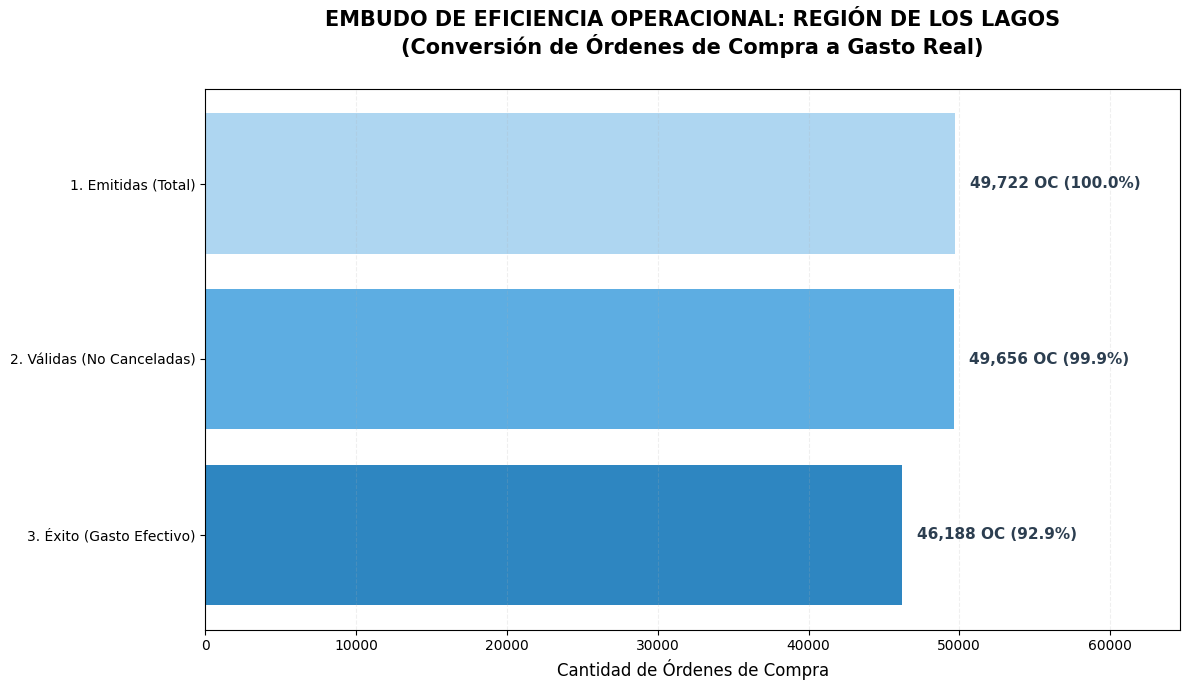

--- VERIFICACIÓN DE DATOS (SOLO LOS LAGOS) ---
Total Órdenes Analizadas: 49722
Tasa de Conversión Final: 92.9%


In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. FILTRO DE HIERRO: Aseguramos que el embudo solo vea a Los Lagos
df_funnel_lagos = df[df['RegionUnidadCompra'] == 'REGION DE LOS LAGOS'].copy()

# 2. Definimos las etapas del embudo con los datos filtrados
total_emitidas = df_funnel_lagos.shape[0]
validas = df_funnel_lagos[df_funnel_lagos['EstadoOC'] != 'Solicitud de Cancelacion'].shape[0]
exito = df_funnel_lagos[df_funnel_lagos['EstadoOC'].isin(['Recepcion Conforme', 'Aceptada'])].shape[0]

etapas_data = {
    '1. Emitidas (Total)': total_emitidas,
    '2. Válidas (No Canceladas)': validas,
    '3. Éxito (Gasto Efectivo)': exito
}

# 3. Convertimos a DataFrame para graficar
df_funnel_plot = pd.DataFrame(list(etapas_data.items()), columns=['Etapa', 'Cantidad'])
df_funnel_plot['Porcentaje'] = (df_funnel_plot['Cantidad'] / total_emitidas * 100).round(1)

# 4. Gráfico de Barras Horizontales (Estilo Embudo)
plt.figure(figsize=(12, 7))
colors = ['#AED6F1', '#5DADE2', '#2E86C1'] # Degradado de azul profesional

bars = plt.barh(df_funnel_plot['Etapa'], df_funnel_plot['Cantidad'], color=colors)

# Invertimos el eje para que el total esté arriba
plt.gca().invert_yaxis()

# Añadir etiquetas de texto con el número y el porcentaje
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + (total_emitidas * 0.02), bar.get_y() + bar.get_height()/2,
             f"{int(width):,} OC ({df_funnel_plot.iloc[i]['Porcentaje']}%)",
             va='center', fontsize=11, fontweight='bold', color='#2C3E50')

plt.title('EMBUDO DE EFICIENCIA OPERACIONAL: REGIÓN DE LOS LAGOS\n(Conversión de Órdenes de Compra a Gasto Real)',
          fontsize=15, fontweight='bold', pad=25)
plt.xlabel('Cantidad de Órdenes de Compra', fontsize=12)
plt.xlim(0, total_emitidas * 1.3) # Espacio para que las etiquetas no se corten
plt.grid(axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('conversion_operacional_lagos.png', dpi=300)
plt.show()

# 📝 Verificación de Integridad para tu Notion
print(f"--- VERIFICACIÓN DE DATOS (SOLO LOS LAGOS) ---")
print(f"Total Órdenes Analizadas: {total_emitidas}")
print(f"Tasa de Conversión Final: {df_funnel_plot.iloc[2]['Porcentaje']}%")

In [30]:
# Verificación final de integridad
total_real_lagos = df[df['RegionUnidadCompra'] == 'REGION DE LOS LAGOS'].shape[0]
print(f"El número total de OC en Los Lagos es: {total_real_lagos}")

El número total de OC en Los Lagos es: 49722


In [31]:
# ==================================================
# MOTOR DE ALERTAS AUTOMÁTICAS: REGIÓN DE LOS LAGOS
# ==================================================

# 1. FILTRO DE ORIGEN: Solo trabajamos con la verdad regional
df_alertas_lagos = df[df['RegionUnidadCompra'] == 'REGION DE LOS LAGOS'].copy()

# 2. CÁLCULO DE UMBRALES REGIONALES (Ticket Promedio)
# Agrupamos primero para tener el ticket promedio de cada institución de Los Lagos
stats_inst_lagos = df_alertas_lagos.groupby(['Sector', 'Institucion']).agg(
    Cant_OC=('codigoOC', 'count'),
    Gasto_Total_Neto=('MontoNetoOC_CLP', 'sum')
).reset_index()

stats_inst_lagos['Ticket_Promedio_MM'] = (stats_inst_lagos['Gasto_Total_Neto'] / stats_inst_lagos['Cant_OC'] / 1000000).round(2)

# Definimos el umbral: 2 veces el promedio REAL de Los Lagos
promedio_real_lagos = stats_inst_lagos['Ticket_Promedio_MM'].mean()
umbral_riesgo = promedio_real_lagos * 2

# ALERTA 1: Ticket Promedio fuera de rango
alertas_ticket_final = stats_inst_lagos[stats_inst_lagos['Ticket_Promedio_MM'] > umbral_riesgo].copy()
alertas_ticket_final['Severidad'] = '🔴 CRÍTICA'

# 3. CÁLCULO DE DOMINANCIA (Concentración de Proveedores)
# ¿Cuánto de la torta de cada institución se lleva cada proveedor en Los Lagos?
gasto_prov_inst = df_alertas_lagos.groupby(['Institucion', 'Proveedor'])['MontoNetoOC_CLP'].sum().reset_index()
gasto_total_inst = df_alertas_lagos.groupby('Institucion')['MontoNetoOC_CLP'].sum().reset_index()

# Unimos para sacar el % de share
monitor_share = pd.merge(gasto_prov_inst, gasto_total_inst, on='Institucion', suffixes=('_Prov', '_TotalInst'))
monitor_share['Share_%'] = (monitor_share['MontoNetoOC_CLP_Prov'] / monitor_share['MontoNetoOC_CLP_TotalInst']) * 100

# ALERTA 2: Dominancia Crítica (>40% del presupuesto de la institución)
alertas_dominancia_final = monitor_share[monitor_share['Share_%'] > 40].sort_values(by='Share_%', ascending=False)

# --- RESULTADOS ---
print(f"🚨 --- AUDITORÍA AUTOMÁTICA: REGIÓN DE LOS LAGOS --- 🚨")
print(f"Benchmark Regional: ${promedio_real_lagos:.2f}M por OC | Umbral Alerta: >${umbral_riesgo:.2f}M\n")

print(f"1. INSTITUCIONES CON SOBRECOSTO CRÍTICO (>2x Promedio):")
if not alertas_ticket_final.empty:
    print(alertas_ticket_final[['Institucion', 'Ticket_Promedio_MM', 'Severidad']].sort_values(by='Ticket_Promedio_MM', ascending=False))
else:
    print("✅ No se detectaron desviaciones críticas.")

print(f"\n2. PROVEEDORES CON DOMINANCIA CRÍTICA EN INSTITUCIONES (>40% Share):")
if not alertas_dominancia_final.empty:
    # Mostramos los top 10 casos de mayor concentración
    print(alertas_dominancia_final[['Institucion', 'Proveedor', 'Share_%']].head(10).round(1))
else:
    print("✅ No se detectaron concentraciones sospechosas.")

# Exportamos el hallazgo de riesgo para el informe final
alertas_ticket_final.to_csv('alertas_gasto_critico_lagos.csv', index=False)

🚨 --- AUDITORÍA AUTOMÁTICA: REGIÓN DE LOS LAGOS --- 🚨
Benchmark Regional: $3.44M por OC | Umbral Alerta: >$6.89M

1. INSTITUCIONES CON SOBRECOSTO CRÍTICO (>2x Promedio):
                       Institucion  Ticket_Promedio_MM  Severidad
37        SERVICIO DE SALUD OSORNO               26.03  🔴 CRÍTICA
16       I MUNICIPALIDAD DE OSORNO               10.91  🔴 CRÍTICA
42  SUBSECRETARIA DE SALUD PUBLICA               10.21  🔴 CRÍTICA

2. PROVEEDORES CON DOMINANCIA CRÍTICA EN INSTITUCIONES (>40% Share):
                                            Institucion  \
7040        SERVICIO DE SALUD OSORNO HOSPITAL PURRANQUE   
326          HOSPITAL FUTA SRÜKA LAWENCHE KUNKO MAPU MO   
178            CORP MUNICIPAL DE PUQUELDON PARA LA EDUC   
5399                       I MUNICIPALIDAD PUERTO OCTAY   
3300                         I MUNICIPALIDAD DE MAULLIN   
7090  SERVICIO NACIONAL DE SALUD HOSPITAL DE PUERTO ...   
4382                       I MUNICIPALIDAD DE PUQUELDON   
5859      ILUSTRE MUNICI

In [32]:
# ==================================================
# CREACIÓN DE ETIQUETAS DE SEMÁFORO (LOGIC ENGINE)
# ==================================================

def definir_alerta(row):
    # Regla: Si supera 2 veces el promedio regional -> ROJO
    if row['Ticket_Promedio_MM'] > (promedio_regional * 2):
        return '🔴 ALTO RIESGO'
    # Regla: Si supera el promedio pero no llega al doble -> AMARILLO
    elif row['Ticket_Promedio_MM'] > promedio_regional:
        return '🟡 PRECAUCIÓN'
    else:
        return '🟢 NORMAL'

# Aplicamos la lógica a nuestra tabla de insights
insight_final['Status_Auditoria'] = insight_final.apply(definir_alerta, axis=1)

# Guardamos este resultado en un EXCEL o CSV final para Power BI
insight_final.to_csv('Reporte_Auditoria_LosLagos.csv', sep=';', index=False)

print("✅ 'Motor de Alerta' finalizado.")
print("Se ha generado el archivo 'Reporte_Auditoria_LosLagos.csv' con semáforos lógicos.")
print(insight_final[['Institucion', 'Status_Auditoria', 'Ticket_Promedio_MM']].head(10))

✅ 'Motor de Alerta' finalizado.
Se ha generado el archivo 'Reporte_Auditoria_LosLagos.csv' con semáforos lógicos.
                                          Institucion Status_Auditoria  \
39  HOSPITAL PUERTO MONTT SERVICIO DE SALUD DEL RE...    🔴 ALTO RIESGO   
40                           SERVICIO DE SALUD CHILOE     🟡 PRECAUCIÓN   
49                       SERVICIO SALUD DEL RELONCAVI     🟡 PRECAUCIÓN   
32                      ILUSTRE MUNICIPALIDAD COCHAMO         🟢 NORMAL   
12                       I MUNICIPALIDAD DE FUTALEUFU         🟢 NORMAL   
13                       I MUNICIPALIDAD DE HUALAIHUE         🟢 NORMAL   
10                          I MUNICIPALIDAD DE FRESIA         🟢 NORMAL   
20                    I MUNICIPALIDAD DE PUERTO MONTT     🟡 PRECAUCIÓN   
24                         I MUNICIPALIDAD DE PUYEHUE         🟢 NORMAL   
36                               HOSPITAL BASE OSORNO    🔴 ALTO RIESGO   

    Ticket_Promedio_MM  
39                5.99  
40                3.0

Algunas correcciones

In [33]:
# ==================================================
# INSIGHT #4: VERSIÓN BLINDADA (Cero KeyErrors)
# ==================================================

# 1. Base de Emisiones (Total OC creadas)
total_oc = df_clean.groupby(['Sector', 'Institucion'])['codigoOC'].count().reset_index()
total_oc.columns = ['Sector', 'Institucion', 'Total_Emitidas']

# 2. Filtro de éxito (Aceptadas y Recepcionadas)
# Usamos .copy() para evitar avisos de Python
df_exito = df_clean[df_clean['EstadoOC'].isin(['Recepcion Conforme', 'Aceptada'])].copy()

# 3. Base de Éxito (Suma y cuenta de las que llegaron a puerto)
exito_stats = df_exito.groupby(['Sector', 'Institucion']).agg(
    Completadas=('codigoOC', 'count'),
    Gasto_Total=('MontoNetoOC_CLP', 'sum')
).reset_index()

# 4. EL JOIN: Unimos ambas tablas
insight_final = pd.merge(total_oc, exito_stats, on=['Sector', 'Institucion'], how='left')

# 5. LIMPIEZA DE NULOS: Si una institución no tiene éxitos, el merge pone NaN. Lo cambiamos a 0.
insight_final = insight_final.fillna(0)

# 6. CÁLCULOS MATEMÁTICOS (Usando .div para mayor seguridad)
insight_final['Tasa_Exito_%'] = (insight_final['Completadas'] / insight_final['Total_Emitidas'] * 100).round(1)

# Creamos el Ticket Promedio evitando la división por cero
# Si Completadas es 0, el resultado será 0
insight_final['Ticket_Promedio_MM'] = 0.0 # La creamos primero vacía
mask = insight_final['Completadas'] > 0 # Solo donde haya éxitos
insight_final.loc[mask, 'Ticket_Promedio_MM'] = (insight_final['Gasto_Total'] / insight_final['Completadas'] / 1000000).round(2)

# 7. ORDENAMIENTO Y CIERRE
insight_final = insight_final.sort_values(by='Total_Emitidas', ascending=False)

print("--- REPORTE FINAL DE EFICIENCIA POR INSTITUCIÓN ---")
# Imprimimos asegurándonos de que las columnas existen
columnas_ver = ['Institucion', 'Sector', 'Total_Emitidas', 'Completadas', 'Tasa_Exito_%', 'Ticket_Promedio_MM']
print(insight_final[columnas_ver].head(10))

--- REPORTE FINAL DE EFICIENCIA POR INSTITUCIÓN ---
                                          Institucion           Sector  \
39  HOSPITAL PUERTO MONTT SERVICIO DE SALUD DEL RE...            SALUD   
40                           SERVICIO DE SALUD CHILOE            SALUD   
49                       SERVICIO SALUD DEL RELONCAVI            SALUD   
32                      ILUSTRE MUNICIPALIDAD COCHAMO  MUNICIPALIDADES   
12                       I MUNICIPALIDAD DE FUTALEUFU  MUNICIPALIDADES   
13                       I MUNICIPALIDAD DE HUALAIHUE  MUNICIPALIDADES   
10                          I MUNICIPALIDAD DE FRESIA  MUNICIPALIDADES   
20                    I MUNICIPALIDAD DE PUERTO MONTT  MUNICIPALIDADES   
24                         I MUNICIPALIDAD DE PUYEHUE  MUNICIPALIDADES   
36                               HOSPITAL BASE OSORNO            SALUD   

    Total_Emitidas  Completadas  Tasa_Exito_%  Ticket_Promedio_MM  
39           11494        11356         98.80                5.99

In [34]:

# Tabla de estados SOLO para Los Lagos (Para que coincida con el embudo)
df_lagos_final = df[df['RegionUnidadCompra'] == 'REGION DE LOS LAGOS']
tabla_notion = df_lagos_final['EstadoOC'].value_counts().reset_index()
tabla_notion.columns = ['Estado de la OC', 'Cantidad']
tabla_notion['%'] = (tabla_notion['Cantidad'] / tabla_notion['Cantidad'].sum() * 100).round(2)

print("--- CALIDAD OPERACIONAL ---")
print(tabla_notion)

--- CALIDAD OPERACIONAL ---
            Estado de la OC  Cantidad     %
0        Recepcion Conforme     29227 58.78
1                  Aceptada     16961 34.11
2       Enviada a Proveedor      3378  6.79
3                En Proceso        90  0.18
4  Solicitud de Cancelacion        66  0.13
